# Descriptive characterization of the 63 DFEA channels

This notebook implements a descriptive characterization of the 63 Meta Face Tracking FEA channels in the canonical EmoHeVRDB-DFEA data.

The analysis uses the canonical DFEA tables for **train, validation, and test**. It characterizes the dataset itself; it does **not** evaluate a trained model and therefore does not restrict the primary summaries to the held-out test set.

The notebook intentionally remains descriptive:

- no hypothesis tests are performed;
- no feature is removed;
- no coefficient threshold is interpreted as an AU-presence threshold;
- the 51,810 time-step rows are not treated as statistically independent samples;
- class-specific FEA patterns are deferred to the next analysis step.

Primary outputs are written to `outputs/03_fea_channel_characterization/`.


## 1. Imports and paths

Run this notebook from:

`emohevrdb-dfer/6_discussion/fea_analysis/`

The preferred input location is the local `data/` directory created by `create_canonical_fea_analysis_datasets.ipynb`. For convenience, the notebook also checks the current working directory so the downloaded notebook can be validated together with the uploaded CSV files.


In [1]:
from pathlib import Path
import json
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ANALYSIS_DIR = Path.cwd()

DATA_DIR_CANDIDATES = [
    ANALYSIS_DIR / "data",
    ANALYSIS_DIR,
]

def first_directory_with_required_files(candidates, filenames):
    for directory in candidates:
        if all((directory / filename).exists() for filename in filenames):
            return directory

    checked = "\n".join(f"  - {directory}" for directory in candidates)
    raise FileNotFoundError(
        "Could not find the canonical DFEA files.\n"
        f"Checked:\n{checked}"
    )

REQUIRED_DFEA_FILES = [
    "dfea_train.csv",
    "dfea_validation.csv",
    "dfea_test.csv",
]

DATA_DIR = first_directory_with_required_files(
    DATA_DIR_CANDIDATES,
    REQUIRED_DFEA_FILES,
)

OUTPUT_DIR = ANALYSIS_DIR / "outputs" / "03_fea_channel_characterization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Data directory: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/data
Output directory: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/outputs/03_fea_channel_characterization


## 2. Canonical schema

The feature list below matches the canonical 63-channel ordering already used by the prediction notebooks and the canonical-dataset notebook.


In [2]:
META_COLUMNS = [
    "reenactment_id",
    "split",
    "sequence_timestamp",
    "set_id",
    "participant_id",
    "level_id",
    "emoji_id",
    "timestep",
    "observation_timestamp",
    "is_reference_observation",
    "true_label_id",
    "true_label",
]

FEA_COLUMNS = [
    "BrowLowererL",
    "BrowLowererR",
    "CheekPuffL",
    "CheekPuffR",
    "CheekRaiserL",
    "CheekRaiserR",
    "CheekSuckL",
    "CheekSuckR",
    "ChinRaiserB",
    "ChinRaiserT",
    "DimplerL",
    "DimplerR",
    "EyesClosedL",
    "EyesClosedR",
    "EyesLookDownL",
    "EyesLookDownR",
    "EyesLookLeftL",
    "EyesLookLeftR",
    "EyesLookRightL",
    "EyesLookRightR",
    "EyesLookUpL",
    "EyesLookUpR",
    "InnerBrowRaiserL",
    "InnerBrowRaiserR",
    "JawDrop",
    "JawSidewaysLeft",
    "JawSidewaysRight",
    "JawThrust",
    "LidTightenerL",
    "LidTightenerR",
    "LipCornerDepressorL",
    "LipCornerDepressorR",
    "LipCornerPullerL",
    "LipCornerPullerR",
    "LipFunnelerLB",
    "LipFunnelerLT",
    "LipFunnelerRB",
    "LipFunnelerRT",
    "LipPressorL",
    "LipPressorR",
    "LipPuckerL",
    "LipPuckerR",
    "LipStretcherL",
    "LipStretcherR",
    "LipSuckLB",
    "LipSuckLT",
    "LipSuckRB",
    "LipSuckRT",
    "LipTightenerL",
    "LipTightenerR",
    "LipsToward",
    "LowerLipDepressorL",
    "LowerLipDepressorR",
    "MouthLeft",
    "MouthRight",
    "NoseWrinklerL",
    "NoseWrinklerR",
    "OuterBrowRaiserL",
    "OuterBrowRaiserR",
    "UpperLidRaiserL",
    "UpperLidRaiserR",
    "UpperLipRaiserL",
    "UpperLipRaiserR",
]

SPLITS = ["train", "validation", "test"]

assert len(FEA_COLUMNS) == 63
assert len(FEA_COLUMNS) == len(set(FEA_COLUMNS))


## 3. Load and validate the canonical DFEA tables

The validation here is intentionally redundant with the dataset-generation notebook. It ensures that this analysis fails early if the canonical tables are changed unexpectedly.

If `canonical_dataset_validation.json` is present, its expected counts are also checked.


In [3]:
dfea = {
    split: pd.read_csv(DATA_DIR / f"dfea_{split}.csv")
    for split in SPLITS
}

validation_path = DATA_DIR / "canonical_dataset_validation.json"
validation = None

if validation_path.exists():
    validation = json.loads(validation_path.read_text(encoding="utf-8"))
    print("Loaded validation metadata:", validation_path)
else:
    print("Validation JSON not found; continuing with direct table checks.")

expected_columns = META_COLUMNS + FEA_COLUMNS

for split, df in dfea.items():
    assert df.columns.tolist() == expected_columns, f"{split}: unexpected columns/order"
    assert df["split"].eq(split).all(), f"{split}: split column mismatch"
    assert not df.duplicated(["reenactment_id", "timestep"]).any(), f"{split}: duplicate canonical keys"
    assert df.groupby("reenactment_id").size().eq(30).all(), f"{split}: sequence length != 30"
    assert df.groupby("reenactment_id")["timestep"].nunique().eq(30).all(), f"{split}: incomplete timesteps"
    assert df[FEA_COLUMNS].notna().all().all(), f"{split}: missing FEA values"

    values = df[FEA_COLUMNS].to_numpy(dtype=float)
    assert np.isfinite(values).all(), f"{split}: non-finite FEA values"
    assert values.min() >= -1e-8, f"{split}: FEA value below 0"
    assert values.max() <= 1.0 + 1e-8, f"{split}: FEA value above 1"

    if validation is not None:
        expected = validation["splits"][split]
        assert len(df) == expected["dfea_rows"]
        assert df["reenactment_id"].nunique() == expected["reenactments"]
        assert df["participant_id"].nunique() == expected["participants"]

all_dfea = pd.concat(
    [dfea[split] for split in SPLITS],
    ignore_index=True,
)

assert len(all_dfea) == sum(len(df) for df in dfea.values())
assert all_dfea["reenactment_id"].nunique() == sum(
    df["reenactment_id"].nunique() for df in dfea.values()
)

print(
    f"Loaded {len(all_dfea):,} time-step rows from "
    f"{all_dfea['reenactment_id'].nunique():,} reenactments and "
    f"{all_dfea['participant_id'].nunique()} participants."
)


Loaded validation metadata: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/data/canonical_dataset_validation.json
Loaded 51,810 time-step rows from 1,727 reenactments and 36 participants.


## 4. Dataset overview

The pooled summaries below are **dataset-composition weighted**. Because each reenactment has exactly 30 observations, every reenactment contributes the same number of time-step rows, but participants and expression categories need not contribute equally.

Participant-balanced analyses are a separate later step in the analysis plan.


In [4]:
overview_rows = []

for split in SPLITS:
    df = dfea[split]
    reenactments = df.drop_duplicates("reenactment_id")

    overview_rows.append({
        "split": split,
        "rows": len(df),
        "reenactments": reenactments["reenactment_id"].nunique(),
        "participants": reenactments["participant_id"].nunique(),
        "classes": reenactments["true_label"].nunique(),
        "minimum_fea": df[FEA_COLUMNS].min().min(),
        "maximum_fea": df[FEA_COLUMNS].max().max(),
    })

overview = pd.DataFrame(overview_rows)
display(overview)

class_counts = (
    all_dfea
    .drop_duplicates("reenactment_id")
    .groupby(["split", "true_label"], observed=True)
    .size()
    .rename("reenactments")
    .reset_index()
)

display(
    class_counts.pivot(
        index="true_label",
        columns="split",
        values="reenactments",
    ).fillna(0).astype(int)
)


,split,rows,reenactments,participants,classes,minimum_fea,maximum_fea
0,train,28920,964,20,7,0.0,1.0
1,validation,11550,385,8,7,0.0,1.0
2,test,11340,378,8,7,0.0,1.0


split,test,train,validation
true_label,,,
Anger,54,66,55
Disgust,54,102,55
Fear,54,105,55
Happiness,54,191,55
Neutral,54,197,55
Sadness,54,131,55
Surprise,54,172,55


## 5. Descriptive statistics for each FEA channel

For each of the 63 channels, the notebook reports:

- count and missing values,
- mean and median,
- standard deviation,
- minimum and maximum,
- 1st, 5th, 25th, 75th, 95th, and 99th percentiles,
- interquartile range (`IQR = P75 - P25`),
- robust central range (`P99 - P01`),
- fractions exactly zero, at or below 0.01 and 0.05,
- fractions at or above 0.95 and 0.99,
- number of unique floating-point values.

The low/high-value fractions are **diagnostics only**. They are not AU-occurrence thresholds.


In [5]:
def compute_feature_summary(df: pd.DataFrame, feature_columns: list[str]) -> pd.DataFrame:
    features = df[feature_columns]

    summary = pd.DataFrame(index=feature_columns)
    summary["n"] = len(df)
    summary["missing"] = features.isna().sum()
    summary["mean"] = features.mean()
    summary["median"] = features.median()
    summary["std"] = features.std(ddof=1)
    summary["min"] = features.min()
    summary["p01"] = features.quantile(0.01)
    summary["p05"] = features.quantile(0.05)
    summary["p25"] = features.quantile(0.25)
    summary["p75"] = features.quantile(0.75)
    summary["p95"] = features.quantile(0.95)
    summary["p99"] = features.quantile(0.99)
    summary["max"] = features.max()
    summary["iqr"] = summary["p75"] - summary["p25"]
    summary["p99_p01"] = summary["p99"] - summary["p01"]
    summary["fraction_eq_0"] = features.eq(0).mean()
    summary["fraction_le_0_01"] = features.le(0.01).mean()
    summary["fraction_le_0_05"] = features.le(0.05).mean()
    summary["fraction_ge_0_95"] = features.ge(0.95).mean()
    summary["fraction_ge_0_99"] = features.ge(0.99).mean()
    summary["n_unique"] = features.nunique()

    return (
        summary
        .reset_index(names="fea_name")
        .sort_values("fea_name")
        .reset_index(drop=True)
    )


global_summary = compute_feature_summary(all_dfea, FEA_COLUMNS)
global_summary.to_csv(
    OUTPUT_DIR / "fea_global_descriptive_statistics.csv",
    index=False,
)

display(global_summary)


,fea_name,n,missing,mean,median,std,min,p01,p05,p25,p75,p95,p99,max,iqr,p99_p01,fraction_eq_0,fraction_le_0_01,fraction_le_0_05,fraction_ge_0_95,fraction_ge_0_99,n_unique
0,BrowLowererL,51810,0,0.123703,3.194790e-02,0.200294,2.630680e-37,2.690906e-16,1.177082e-08,1.028766e-03,0.151373,0.609281,0.891512,1.000000,0.150344,0.891512,0.000000,0.372457,0.562575,0.004787,0.002586,45599
1,BrowLowererR,51810,0,0.109368,2.375243e-02,0.188024,2.802597e-45,7.190320e-20,7.289109e-10,5.059132e-04,0.126808,0.556564,0.859285,1.000000,0.126302,0.859285,0.000000,0.397124,0.600039,0.004266,0.002374,45529
2,CheekPuffL,51810,0,0.003850,1.736212e-13,0.015762,0.000000e+00,1.401298e-45,1.401298e-45,6.459997e-31,0.000014,0.025011,0.058813,0.548189,0.000014,0.058813,0.004053,0.866010,0.987223,0.000000,0.000000,36224
3,CheekPuffR,51810,0,0.004379,2.163967e-12,0.015757,0.000000e+00,1.401298e-45,1.401298e-45,5.941077e-28,0.000081,0.027160,0.061148,0.546313,0.000081,0.061148,0.004053,0.852094,0.984366,0.000000,0.000000,37017
4,CheekRaiserL,51810,0,0.157260,5.428495e-02,0.225066,1.401298e-45,8.857717e-20,2.706395e-09,1.086558e-02,0.203490,0.682907,0.929052,1.000000,0.192624,0.929052,0.000000,0.224667,0.487917,0.008550,0.006562,44804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,OuterBrowRaiserR,51810,0,0.070421,1.073003e-02,0.148028,2.802597e-45,4.408765e-27,1.248315e-13,9.699588e-05,0.063337,0.390491,0.761543,1.000000,0.063240,0.761543,0.000000,0.492260,0.717236,0.001641,0.001390,45372
59,UpperLidRaiserL,51810,0,0.089008,1.046639e-07,0.197741,1.401298e-45,1.401298e-45,1.401298e-45,1.631878e-23,0.043107,0.606858,0.877492,0.993172,0.043107,0.877492,0.000000,0.657518,0.760567,0.001525,0.000039,39021
60,UpperLidRaiserR,51810,0,0.111375,6.362187e-07,0.219646,1.401298e-45,1.401298e-45,1.401298e-45,2.600935e-27,0.081587,0.675289,0.862046,0.998252,0.081587,0.862046,0.000000,0.623760,0.720421,0.001544,0.000116,36716
61,UpperLipRaiserL,51810,0,0.129132,1.572390e-02,0.196073,1.401298e-45,2.173427e-41,6.813176e-24,1.315302e-08,0.200136,0.583034,0.760595,0.999994,0.200136,0.760595,0.000000,0.445783,0.583961,0.000174,0.000097,44908


## 6. Split-specific summaries

These tables are a consistency diagnostic. A visible train/validation/test difference is not automatically an error: the splits contain different participants, and the training split is not class-balanced in the same way as validation and test.

The goal is to identify channels whose marginal distributions differ substantially enough to deserve attention in later analyses.


In [6]:
split_summaries = []

for split in SPLITS:
    summary = compute_feature_summary(dfea[split], FEA_COLUMNS)
    summary.insert(0, "split", split)
    split_summaries.append(summary)

split_summary = pd.concat(split_summaries, ignore_index=True)

split_summary.to_csv(
    OUTPUT_DIR / "fea_split_descriptive_statistics.csv",
    index=False,
)

split_means = (
    split_summary
    .pivot(index="fea_name", columns="split", values="mean")
    .reindex(FEA_COLUMNS)
)

split_medians = (
    split_summary
    .pivot(index="fea_name", columns="split", values="median")
    .reindex(FEA_COLUMNS)
)

pooled = global_summary.set_index("fea_name")

split_consistency = pd.DataFrame(index=FEA_COLUMNS)
for split in SPLITS:
    split_consistency[f"{split}_mean"] = split_means[split]
    split_consistency[f"{split}_median"] = split_medians[split]

split_consistency["mean_range_across_splits"] = (
    split_means.max(axis=1) - split_means.min(axis=1)
)
split_consistency["median_range_across_splits"] = (
    split_medians.max(axis=1) - split_medians.min(axis=1)
)
split_consistency["max_abs_mean_deviation_from_pooled"] = pd.concat(
    [
        (split_means[split] - pooled["mean"]).abs()
        for split in SPLITS
    ],
    axis=1,
).max(axis=1)
split_consistency["max_abs_median_deviation_from_pooled"] = pd.concat(
    [
        (split_medians[split] - pooled["median"]).abs()
        for split in SPLITS
    ],
    axis=1,
).max(axis=1)

split_consistency = (
    split_consistency
    .reset_index(names="fea_name")
    .sort_values("mean_range_across_splits", ascending=False)
    .reset_index(drop=True)
)

split_consistency.to_csv(
    OUTPUT_DIR / "fea_split_consistency.csv",
    index=False,
)

display(split_consistency.head(20))


,fea_name,train_mean,train_median,validation_mean,validation_median,test_mean,test_median,mean_range_across_splits,median_range_across_splits,max_abs_mean_deviation_from_pooled,max_abs_median_deviation_from_pooled
0,BrowLowererL,0.099096,2.497654e-02,0.202269,6.858048e-02,0.106436,3.058851e-02,0.103174,0.043604,0.078567,0.036633
1,BrowLowererR,0.086278,1.758978e-02,0.177673,5.240838e-02,0.098683,2.609709e-02,0.091395,0.034819,0.068305,0.028656
2,NoseWrinklerL,0.054754,1.444749e-10,0.136576,1.177337e-03,0.080191,9.252635e-07,0.081822,0.001177,0.058014,0.001177
3,NoseWrinklerR,0.055067,1.320052e-12,0.136491,1.805861e-05,0.079520,2.345825e-09,0.081423,0.000018,0.057920,0.000018
4,UpperLidRaiserR,0.079177,8.825383e-09,0.147205,6.059653e-07,0.156994,8.128265e-03,0.077817,0.008128,0.045619,0.008128
5,LidTightenerR,0.119856,1.291328e-02,0.149969,3.500140e-02,0.193639,1.095589e-01,0.073783,0.096646,0.050921,0.083297
6,CheekRaiserL,0.128053,3.552458e-02,0.195847,7.955649e-02,0.192444,8.585998e-02,0.067794,0.050335,0.038587,0.031575
7,LidTightenerL,0.113703,1.687352e-02,0.135229,2.589913e-02,0.178098,9.252162e-02,0.064395,0.075648,0.045502,0.065876
8,InnerBrowRaiserR,0.060775,1.446689e-02,0.124041,4.882282e-02,0.103943,2.870939e-02,0.063266,0.034356,0.039714,0.025602
9,LipCornerDepressorL,0.073123,1.585805e-03,0.135001,1.086070e-02,0.092597,1.086564e-02,0.061878,0.009280,0.043821,0.007040


## 7. Diagnostic rankings

No channel is labeled as "uninformative" or removed here. Instead, the notebook exposes several complementary diagnostics.

`P99 - P01` is especially useful because it is less dominated by rare extreme values than the full `max - min` range.


In [7]:
ranking_columns = [
    "fea_name",
    "mean",
    "median",
    "std",
    "iqr",
    "p99_p01",
    "fraction_eq_0",
    "fraction_le_0_01",
    "fraction_le_0_05",
    "fraction_ge_0_95",
    "fraction_ge_0_99",
]

print("Highest average coefficients")
display(
    global_summary
    .sort_values("mean", ascending=False)
    [ranking_columns]
    .head(15)
)

print("Smallest robust P99-P01 range")
display(
    global_summary
    .sort_values("p99_p01")
    [ranking_columns]
    .head(15)
)

print("Largest robust P99-P01 range")
display(
    global_summary
    .sort_values("p99_p01", ascending=False)
    [ranking_columns]
    .head(15)
)

print("Largest fraction of values <= 0.01")
display(
    global_summary
    .sort_values("fraction_le_0_01", ascending=False)
    [ranking_columns]
    .head(15)
)


Highest average coefficients


,fea_name,mean,median,std,iqr,p99_p01,fraction_eq_0,fraction_le_0_01,fraction_le_0_05,fraction_ge_0_95,fraction_ge_0_99
4,CheekRaiserL,0.157260,5.428495e-02,0.225066,0.192624,0.929052,0.000000,0.224667,0.487917,0.008550,0.006562
29,LidTightenerR,0.142719,2.626213e-02,0.207946,0.230627,0.798318,0.000000,0.430670,0.559274,0.000791,0.000212
5,CheekRaiserR,0.141075,3.802964e-02,0.218432,0.157894,0.929104,0.000000,0.265798,0.537811,0.008686,0.006755
62,UpperLipRaiserR,0.133892,1.718088e-02,0.201114,0.209869,0.783252,0.000000,0.426829,0.580718,0.000232,0.000174
28,LidTightenerL,0.132596,2.664542e-02,0.191590,0.217567,0.753726,0.000000,0.425343,0.561378,0.000656,0.000637
9,ChinRaiserT,0.132438,3.796319e-02,0.203543,0.160148,0.852701,0.000000,0.337676,0.540822,0.003764,0.002644
61,UpperLipRaiserL,0.129132,1.572390e-02,0.196073,0.200136,0.760595,0.000000,0.445783,0.583961,0.000174,0.000097
0,BrowLowererL,0.123703,3.194790e-02,0.200294,0.150344,0.891512,0.000000,0.372457,0.562575,0.004787,0.002586
17,EyesLookLeftR,0.113839,6.261636e-02,0.134109,0.197297,0.502507,0.364891,0.386084,0.473287,0.000000,0.000000
60,UpperLidRaiserR,0.111375,6.362187e-07,0.219646,0.081587,0.862046,0.000000,0.623760,0.720421,0.001544,0.000116


Smallest robust P99-P01 range


,fea_name,mean,median,std,iqr,p99_p01,fraction_eq_0,fraction_le_0_01,fraction_le_0_05,fraction_ge_0_95,fraction_ge_0_99
7,CheekSuckR,0.000906,0.000000e+00,0.012105,1.401298e-45,0.017224,0.556688,0.989037,0.995078,0.000000,0.000000
6,CheekSuckL,0.000868,1.401298e-45,0.010879,1.401298e-45,0.019049,0.302799,0.988091,0.994847,0.000000,0.000000
54,MouthRight,0.001587,2.716501e-21,0.007899,1.727007e-07,0.026789,0.004053,0.932407,0.996642,0.000000,0.000000
53,MouthLeft,0.004545,3.132471e-07,0.010651,8.447389e-03,0.037083,0.000000,0.771820,0.995619,0.000000,0.000000
2,CheekPuffL,0.003850,1.736212e-13,0.015762,1.366455e-05,0.058813,0.004053,0.866010,0.987223,0.000000,0.000000
3,CheekPuffR,0.004379,2.163967e-12,0.015757,8.057499e-05,0.061148,0.004053,0.852094,0.984366,0.000000,0.000000
25,JawSidewaysLeft,0.008119,1.712328e-08,0.023170,9.584588e-03,0.096753,0.000000,0.757711,0.958406,0.000000,0.000000
26,JawSidewaysRight,0.010198,2.360214e-03,0.025234,1.086360e-02,0.097683,0.000000,0.609959,0.961282,0.000000,0.000000
39,LipPressorR,0.005411,3.376790e-21,0.034554,3.544156e-09,0.157970,0.000000,0.911156,0.978633,0.000000,0.000000
38,LipPressorL,0.005420,3.850293e-20,0.034396,4.762216e-09,0.158452,0.011002,0.908242,0.978769,0.000000,0.000000


Largest robust P99-P01 range


,fea_name,mean,median,std,iqr,p99_p01,fraction_eq_0,fraction_le_0_01,fraction_le_0_05,fraction_ge_0_95,fraction_ge_0_99
56,NoseWrinklerR,0.078571,2.058645e-10,0.209494,0.010846,1.000000,0.000000,0.739394,0.815402,0.019456,0.016310
33,LipCornerPullerR,0.109934,3.737580e-06,0.259843,0.027842,1.000000,0.000000,0.639104,0.783555,0.032581,0.026250
32,LipCornerPullerL,0.107090,2.506435e-04,0.253336,0.027824,1.000000,0.000000,0.606929,0.786547,0.028006,0.019919
55,NoseWrinklerL,0.078562,1.862736e-08,0.207972,0.011916,1.000000,0.000000,0.684810,0.817912,0.018568,0.015866
5,CheekRaiserR,0.141075,3.802964e-02,0.218432,0.157894,0.929104,0.000000,0.265798,0.537811,0.008686,0.006755
4,CheekRaiserL,0.157260,5.428495e-02,0.225066,0.192624,0.929052,0.000000,0.224667,0.487917,0.008550,0.006562
30,LipCornerDepressorL,0.091180,8.625825e-03,0.207544,0.030801,0.901944,0.000000,0.520421,0.779444,0.005655,0.003301
0,BrowLowererL,0.123703,3.194790e-02,0.200294,0.150344,0.891512,0.000000,0.372457,0.562575,0.004787,0.002586
31,LipCornerDepressorR,0.084757,1.147308e-04,0.202301,0.025010,0.881437,0.000000,0.638506,0.797066,0.003957,0.002606
59,UpperLidRaiserL,0.089008,1.046639e-07,0.197741,0.043107,0.877492,0.000000,0.657518,0.760567,0.001525,0.000039


Largest fraction of values <= 0.01


,fea_name,mean,median,std,iqr,p99_p01,fraction_eq_0,fraction_le_0_01,fraction_le_0_05,fraction_ge_0_95,fraction_ge_0_99
7,CheekSuckR,0.000906,0.000000e+00,0.012105,1.401298e-45,0.017224,0.556688,0.989037,0.995078,0.000000,0.000000
6,CheekSuckL,0.000868,1.401298e-45,0.010879,1.401298e-45,0.019049,0.302799,0.988091,0.994847,0.000000,0.000000
34,LipFunnelerLB,0.011047,1.401298e-45,0.068783,2.874777e-20,0.325565,0.056707,0.941285,0.962073,0.001004,0.000907
36,LipFunnelerRB,0.010924,2.043354e-38,0.067476,2.213658e-13,0.315120,0.026732,0.935186,0.962266,0.000926,0.000888
54,MouthRight,0.001587,2.716501e-21,0.007899,1.727007e-07,0.026789,0.004053,0.932407,0.996642,0.000000,0.000000
39,LipPressorR,0.005411,3.376790e-21,0.034554,3.544156e-09,0.157970,0.000000,0.911156,0.978633,0.000000,0.000000
38,LipPressorL,0.005420,3.850293e-20,0.034396,4.762216e-09,0.158452,0.011002,0.908242,0.978769,0.000000,0.000000
2,CheekPuffL,0.003850,1.736212e-13,0.015762,1.366455e-05,0.058813,0.004053,0.866010,0.987223,0.000000,0.000000
3,CheekPuffR,0.004379,2.163967e-12,0.015757,8.057499e-05,0.061148,0.004053,0.852094,0.984366,0.000000,0.000000
49,LipTightenerR,0.024764,2.998085e-17,0.081540,7.155028e-07,0.434634,0.000000,0.831461,0.882224,0.000097,0.000000


## 8. Figure: pooled mean by FEA channel

The plot is sorted for readability. It describes marginal coefficient magnitude only; it does not show expression specificity.


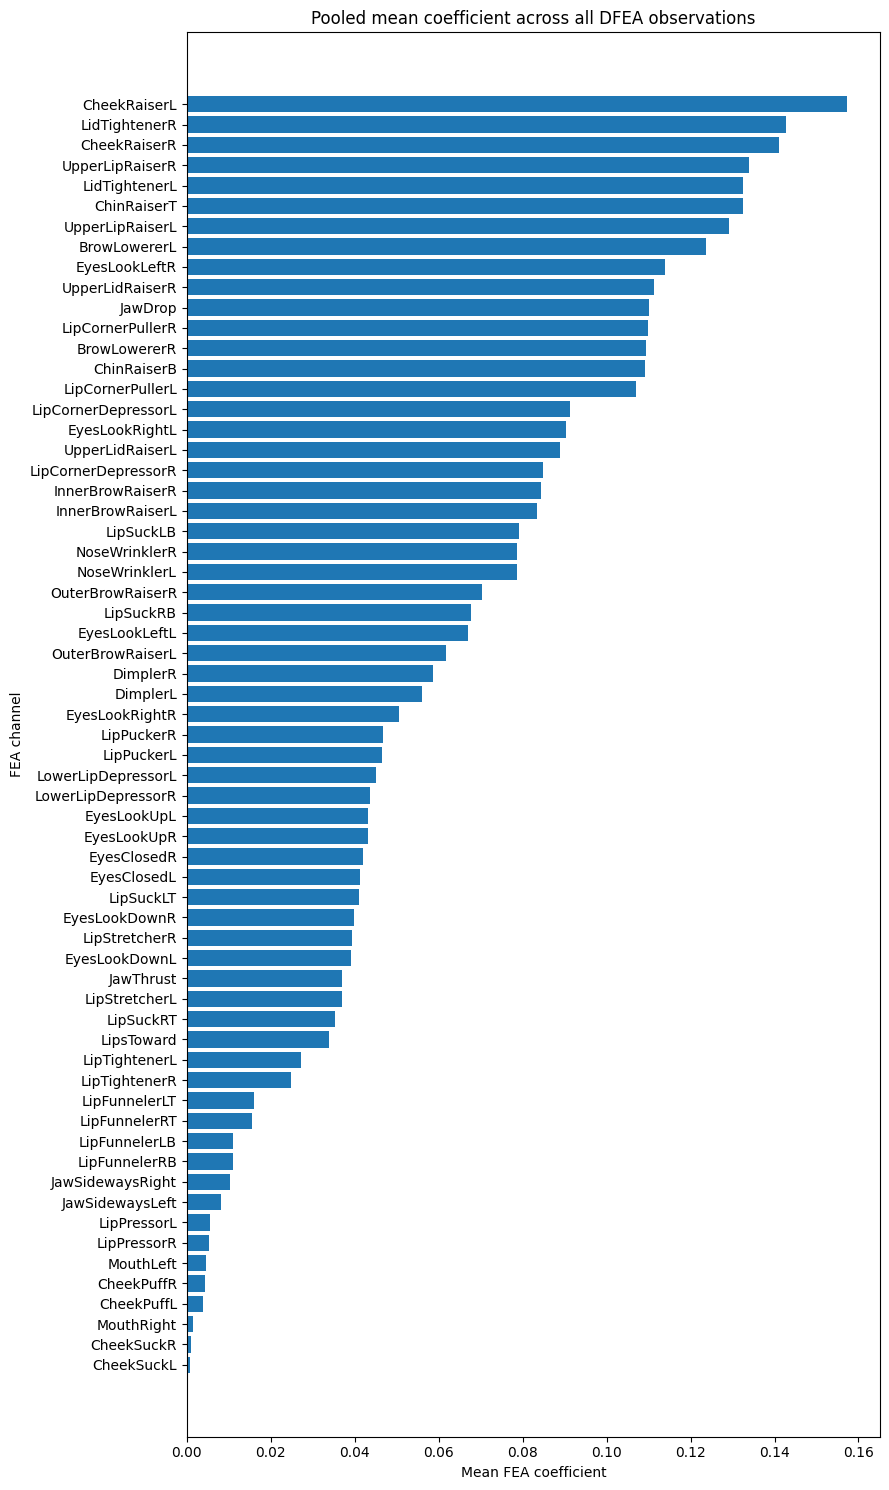

In [8]:
plot_data = global_summary.sort_values("mean", ascending=True)

plt.figure(figsize=(9, 15))
plt.barh(plot_data["fea_name"], plot_data["mean"])
plt.xlabel("Mean FEA coefficient")
plt.ylabel("FEA channel")
plt.title("Pooled mean coefficient across all DFEA observations")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "fea_pooled_mean.png",
    dpi=200,
    bbox_inches="tight",
)
plt.savefig(
    OUTPUT_DIR / "fea_pooled_mean.pdf",
    bbox_inches="tight",
)
plt.show()


## 9. Figure: robust variation by FEA channel

`P99 - P01` summarizes the range containing the central 98% of observed coefficient values. This is used as a descriptive robust-spread measure, not as a feature-selection criterion.


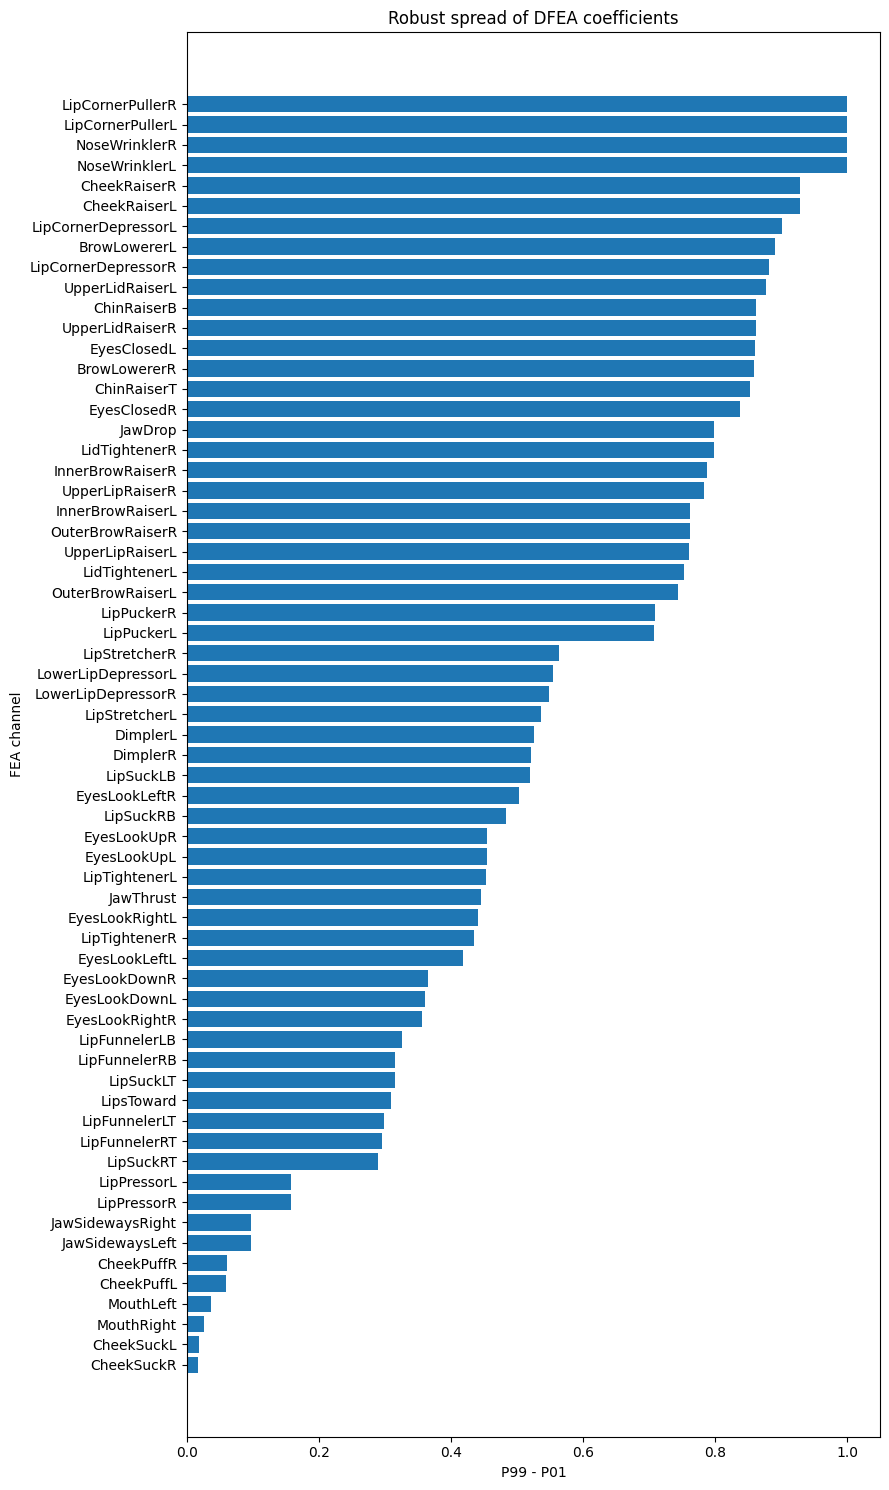

In [9]:
plot_data = global_summary.sort_values("p99_p01", ascending=True)

plt.figure(figsize=(9, 15))
plt.barh(plot_data["fea_name"], plot_data["p99_p01"])
plt.xlabel("P99 - P01")
plt.ylabel("FEA channel")
plt.title("Robust spread of DFEA coefficients")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "fea_robust_spread_p99_p01.png",
    dpi=200,
    bbox_inches="tight",
)
plt.savefig(
    OUTPUT_DIR / "fea_robust_spread_p99_p01.pdf",
    bbox_inches="tight",
)
plt.show()


## 10. Figure: low- and high-value prevalence

This heatmap makes sparse/near-zero and near-saturated channels visible without imposing a single arbitrary threshold.

The displayed fractions are descriptive properties of the Meta coefficients and must not be interpreted as FACS AU occurrence rates.


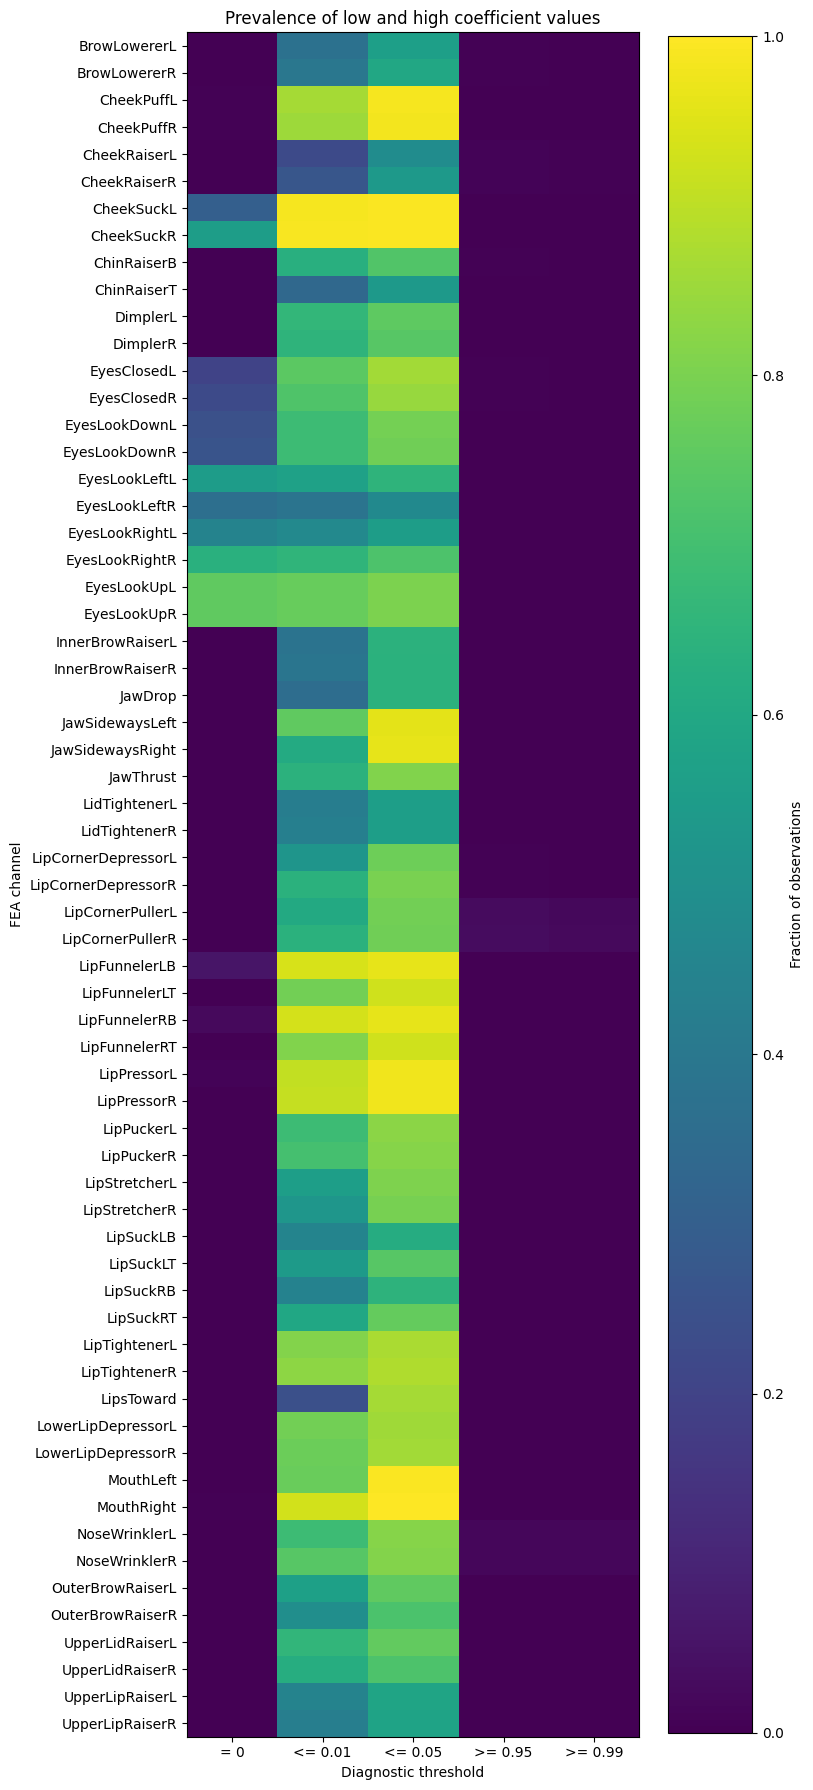

In [10]:
threshold_columns = [
    "fraction_eq_0",
    "fraction_le_0_01",
    "fraction_le_0_05",
    "fraction_ge_0_95",
    "fraction_ge_0_99",
]

threshold_labels = [
    "= 0",
    "<= 0.01",
    "<= 0.05",
    ">= 0.95",
    ">= 0.99",
]

threshold_matrix = (
    global_summary
    .set_index("fea_name")
    .loc[FEA_COLUMNS, threshold_columns]
)

plt.figure(figsize=(8, 18))
image = plt.imshow(threshold_matrix.to_numpy(), aspect="auto", vmin=0, vmax=1)
plt.colorbar(image, label="Fraction of observations")
plt.xticks(
    np.arange(len(threshold_labels)),
    threshold_labels,
)
plt.yticks(
    np.arange(len(FEA_COLUMNS)),
    FEA_COLUMNS,
)
plt.xlabel("Diagnostic threshold")
plt.ylabel("FEA channel")
plt.title("Prevalence of low and high coefficient values")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "fea_threshold_prevalence.png",
    dpi=200,
    bbox_inches="tight",
)
plt.savefig(
    OUTPUT_DIR / "fea_threshold_prevalence.pdf",
    bbox_inches="tight",
)
plt.show()


## 11. Figure: split-specific mean coefficients

This visualization is a diagnostic for marginal train/validation/test differences. It should not be read as an inferential split comparison.


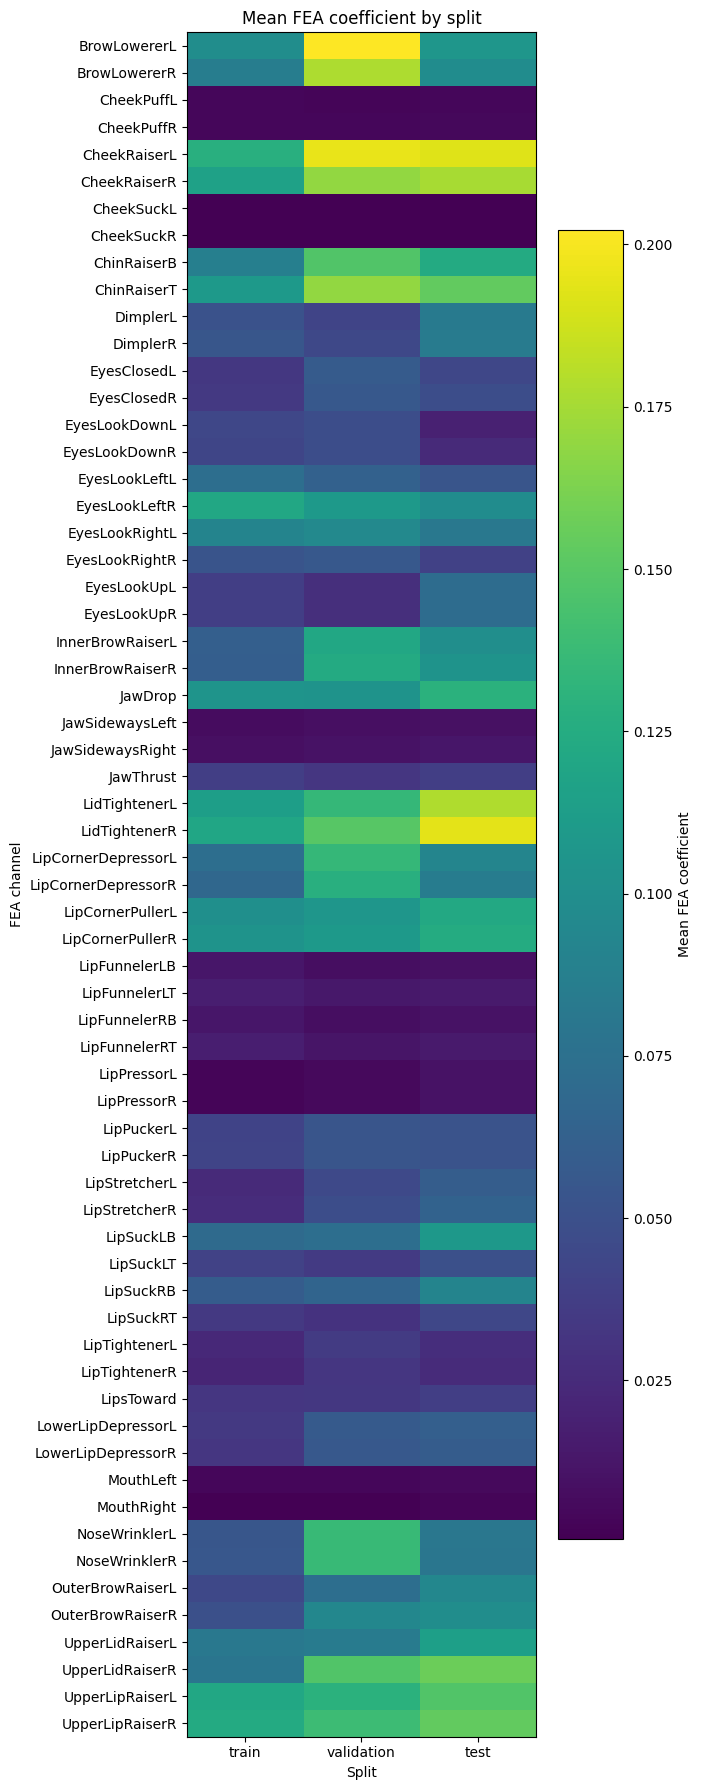

In [11]:
split_mean_matrix = split_means.loc[FEA_COLUMNS, SPLITS]

plt.figure(figsize=(7, 18))
image = plt.imshow(split_mean_matrix.to_numpy(), aspect="auto")
plt.colorbar(image, label="Mean FEA coefficient")
plt.xticks(np.arange(len(SPLITS)), SPLITS)
plt.yticks(np.arange(len(FEA_COLUMNS)), FEA_COLUMNS)
plt.xlabel("Split")
plt.ylabel("FEA channel")
plt.title("Mean FEA coefficient by split")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "fea_split_means.png",
    dpi=200,
    bbox_inches="tight",
)
plt.savefig(
    OUTPUT_DIR / "fea_split_means.pdf",
    bbox_inches="tight",
)
plt.show()


## 12. Per-channel distribution appendix

For detailed manual inspection, this cell writes one histogram per FEA channel into a single multi-page PDF.

The histograms pool all three splits and are intended as a diagnostic appendix. They do not replace later class-wise or participant-balanced analyses.


In [12]:
histogram_pdf_path = OUTPUT_DIR / "fea_channel_histograms.pdf"

with PdfPages(histogram_pdf_path) as pdf:
    for fea_name in FEA_COLUMNS:
        values = all_dfea[fea_name].to_numpy()

        plt.figure(figsize=(8, 5))
        plt.hist(values, bins=50)
        plt.xlabel("FEA coefficient")
        plt.ylabel("Observation count")
        plt.title(f"{fea_name} — pooled DFEA distribution")
        plt.xlim(0, 1)
        plt.tight_layout()

        pdf.savefig(bbox_inches="tight")
        plt.close()

print("Saved:", histogram_pdf_path)


Saved: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/outputs/03_fea_channel_characterization/fea_channel_histograms.pdf


## 13. Export a compact machine-readable diagnostic table

This table brings together the most relevant global and split-consistency diagnostics for later analyses. It is a convenience table, not an additional statistical analysis.


In [13]:
diagnostics = (
    global_summary
    .merge(
        split_consistency,
        on="fea_name",
        how="left",
        validate="one_to_one",
    )
)

diagnostics.to_csv(
    OUTPUT_DIR / "fea_channel_diagnostics.csv",
    index=False,
)

display(diagnostics.head())


,fea_name,n,missing,mean,median,std,min,p01,p05,p25,p75,p95,p99,max,iqr,p99_p01,fraction_eq_0,fraction_le_0_01,fraction_le_0_05,fraction_ge_0_95,fraction_ge_0_99,n_unique,train_mean,train_median,validation_mean,validation_median,test_mean,test_median,mean_range_across_splits,median_range_across_splits,max_abs_mean_deviation_from_pooled,max_abs_median_deviation_from_pooled
0,BrowLowererL,51810,0,0.123703,3.194790e-02,0.200294,2.630680e-37,2.690906e-16,1.177082e-08,1.028766e-03,0.151373,0.609281,0.891512,1.000000,0.150344,0.891512,0.000000,0.372457,0.562575,0.004787,0.002586,45599,0.099096,2.497654e-02,0.202269,6.858048e-02,0.106436,3.058851e-02,0.103174,4.360394e-02,0.078567,3.663258e-02
1,BrowLowererR,51810,0,0.109368,2.375243e-02,0.188024,2.802597e-45,7.190320e-20,7.289109e-10,5.059132e-04,0.126808,0.556564,0.859285,1.000000,0.126302,0.859285,0.000000,0.397124,0.600039,0.004266,0.002374,45529,0.086278,1.758978e-02,0.177673,5.240838e-02,0.098683,2.609709e-02,0.091395,3.481860e-02,0.068305,2.865595e-02
2,CheekPuffL,51810,0,0.003850,1.736212e-13,0.015762,0.000000e+00,1.401298e-45,1.401298e-45,6.459997e-31,0.000014,0.025011,0.058813,0.548189,0.000014,0.058813,0.004053,0.866010,0.987223,0.000000,0.000000,36224,0.003944,3.352642e-14,0.003333,2.202086e-12,0.004139,5.676201e-13,0.000806,2.168559e-12,0.000517,2.028465e-12
3,CheekPuffR,51810,0,0.004379,2.163967e-12,0.015757,0.000000e+00,1.401298e-45,1.401298e-45,5.941077e-28,0.000081,0.027160,0.061148,0.546313,0.000081,0.061148,0.004053,0.852094,0.984366,0.000000,0.000000,37017,0.004386,2.619313e-13,0.003865,6.777752e-12,0.004886,3.746336e-11,0.001022,3.720143e-11,0.000515,3.529939e-11
4,CheekRaiserL,51810,0,0.157260,5.428495e-02,0.225066,1.401298e-45,8.857717e-20,2.706395e-09,1.086558e-02,0.203490,0.682907,0.929052,1.000000,0.192624,0.929052,0.000000,0.224667,0.487917,0.008550,0.006562,44804,0.128053,3.552458e-02,0.195847,7.955649e-02,0.192444,8.585998e-02,0.067794,5.033541e-02,0.038587,3.157503e-02


## 14. Interpretation and decisions for subsequent analyses

The descriptive results above are not only a quality check. They determine how the 30-step sequences should be summarized in the next analysis stages.

### 14.1 Why the sequence median should not be the primary summary

The pooled FEA distributions are strongly concentrated near zero for many channels. Across the current DFEA data:

- the pooled mean is larger than the pooled median for all 63 channels;
- 45/63 channels have a median at or below 0.01;
- 61/63 channels have a median at or below 0.05;
- 12/63 channels have at least 80% of their observations at or below 0.01.

This is consistent with many channels being sparse or episodically active. A sequence median would therefore often collapse a meaningful but temporally limited activation to a value close to zero.

**Decision:** do not use the sequence median as the primary aggregation for category-level FEA profiles.

### 14.2 Why the sequence maximum should not be the primary summary

At the other extreme, a maximum depends on a single observation. Many FEA channels occasionally approach the upper bound of the Meta coefficient range, and several channels show values near 1.0 even at very high percentiles.

A maximum would therefore be highly sensitive to:

- a single brief activation,
- tracker noise,
- an isolated extreme coefficient, or
- coefficient saturation.

**Decision:** do not use the sequence maximum as the primary aggregation. It may remain useful as a diagnostic in later temporal analyses.

### 14.3 Primary sequence aggregation: mean

For each reenactment \(r\) and FEA channel \(f\), the primary sequence-level value will be

\[
\bar{x}_{r,f} = \frac{1}{30}\sum_{t=1}^{30} x_{r,t,f}.
\]

Because all DFEA sequences contain exactly 30 observations, this is also the normalized area under the observed 30-step trajectory.

The mean:

- uses all 30 observations;
- preserves moderate and sustained activation;
- does not reduce sparse channels to zero as aggressively as the median; and
- is substantially less dependent on a single time step than the maximum.

**Decision:** use the 30-step sequence mean as the primary reenactment-level FEA summary.

### 14.4 Sensitivity aggregation: P90

The descriptive distributions also show that some channels are activated only briefly. To retain sensitivity to such stronger short-lived activations without relying on a single maximum, the 90th percentile of the 30 observations will be computed as a secondary sequence summary.

With 30 observations, P90 reflects approximately the upper few observations of the sequence rather than only one point.

**Decision:** use sequence P90 as a sensitivity analysis alongside the sequence mean.

A finding that appears under both mean and P90 is more robust to the choice of temporal aggregation. A pattern that is pronounced only for P90 may indicate a shorter or more episodic activation and should later be examined in the full 1-30 trajectories.

### 14.5 Sample weighting and participant balancing answer different questions

After reducing every sequence to one value per FEA, category-level summaries can be aggregated in two ways.

#### Sample-weighted / reenactment-weighted

Each reenactment contributes once:

\[
\bar{x}_{c,f}
=
\frac{1}{N_c}
\sum_{r \in c}
x_{r,f}.
\]

This is the ordinary mean over the available reenactments. A participant with more reenactments for a category therefore contributes more observations.

This answers:

> What is the average FEA pattern across the reenactments that actually exist in EmoHeVRDB for this category?

**Decision:** use this as the primary dataset-characterization view.

#### Participant-balanced

First average the reenactments within each Participant × Category combination, then average these participant-level values:

\[
\bar{x}^{PB}_{c,f}
=
\frac{1}{P_c}
\sum_p
\left(
\frac{1}{N_{p,c}}
\sum_{r \in (p,c)}
x_{r,f}
\right).
\]

Here, each participant with data for the category receives the same weight.

This answers:

> What is the average category-specific FEA pattern across participants when participants with more reenactments are not allowed to dominate the estimate?

The current canonical data contain unequal numbers of reenactments per Participant × Category combination, so this is a meaningful robustness check.

**Decision:** retain the sample-weighted profile as the primary dataset description and use participant-balanced profiles as a robustness/generalizability check.

Participant balancing is a **weighting choice**, not a normalization of the FEA coefficients.

### 14.6 Participant-specific neutral centering is a separate sensitivity analysis

Participant balancing should not be confused with baseline correction.

For a participant \(p\), category \(c\), and FEA \(f\), a neutral-relative quantity can be computed as

\[
\Delta_{p,c,f}
=
\bar{x}_{p,c,f}
-
\bar{x}_{p,\mathrm{Neutral},f}.
\]

All participants in the current canonical data have Neutral reenactments, so this analysis is feasible.

This answers:

> How does a participant's FEA pattern for a category differ from that participant's own neutral baseline?

This may reduce participant-specific offsets caused by individual facial morphology, reenactment style, or the proprietary tracking representation.

**Decision:** keep raw coefficients as the primary representation and use participant-specific neutral centering as a sensitivity analysis. Do not apply category-wise centering that would remove the category differences of interest.

### 14.7 Raw magnitudes and cross-channel comparisons should remain separate

The 63 FEA channels have very different marginal distributions. Therefore a channel with a larger raw coefficient range can show a larger numerical category difference even when the relative category specificity is not stronger.

Later category analyses should therefore preserve two complementary views:

1. **raw [0,1] coefficient summaries**, which retain the original Meta coefficient scale; and
2. **channel-wise standardized relative summaries**, computed from reenactment-level sequence summaries, when the goal is to compare category-associated deviations across different FEA channels.

Standardization is a visualization/comparison aid and must not replace the raw-value results.

### 14.8 Split handling

Train, validation, and test are combined for the primary descriptive characterization because the target here is the dataset rather than held-out model performance. However, several channels show visible marginal differences between splits.

**Decision:** future dataset-level FEA analyses may use all splits, but important patterns should be checked for qualitative consistency across train, validation, and test.

Final model evaluation, prediction-error analysis, prediction trajectories, and model-reliance analyses remain **test-only**.

### 14.9 Planned aggregation grid for the next analysis step

The next category-level analysis should therefore compute at least:

| Sequence summary | Category aggregation | Purpose |
| --- | --- | --- |
| Mean | Sample-weighted | Primary dataset characterization |
| Mean | Participant-balanced | Participant-robustness check |
| P90 | Sample-weighted | Sensitivity to stronger/episodic activation |
| P90 | Participant-balanced | Participant-robust P90 check |

For Mean and P90, an additional participant-specific neutral-centered version should be generated as a sensitivity analysis.

These variants should be computed first and compared before choosing the most compact representation for the paper.


## 15. Generate an interpretation-focused Markdown report

The report records the empirical findings above together with the aggregation decisions and interpretation rules that follow from them. It is intended to provide the methodological bridge to the category-level analyses in later steps.


In [14]:
def markdown_table(df: pd.DataFrame, columns: list[str], n: int = 10) -> str:
    """Create a small Markdown table without the optional `tabulate` package."""
    table = df[columns].head(n).copy()

    def format_value(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.4f}"
        return str(value)

    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = [
        "| " + " | ".join(format_value(value) for value in row) + " |"
        for row in table.itertuples(index=False, name=None)
    ]
    return "\n".join([header, separator, *rows])


highest_mean = global_summary.sort_values("mean", ascending=False)
smallest_spread = global_summary.sort_values("p99_p01", ascending=True)
largest_spread = global_summary.sort_values("p99_p01", ascending=False)
largest_split_difference = split_consistency.sort_values(
    "mean_range_across_splits",
    ascending=False,
)

summary_indexed = global_summary.set_index("fea_name")

n_mean_gt_median = int((summary_indexed["mean"] > summary_indexed["median"]).sum())
n_median_le_001 = int((summary_indexed["median"] <= 0.01).sum())
n_median_le_005 = int((summary_indexed["median"] <= 0.05).sum())
n_sparse_80 = int((summary_indexed["fraction_le_0_01"] >= 0.80).sum())
n_near_upper_bound = int(np.isclose(summary_indexed["max"], 1.0, atol=1e-8).sum())
n_p99_near_upper_bound = int(np.isclose(summary_indexed["p99"], 1.0, atol=1e-8).sum())
n_split_mean_range_gt_005 = int(
    (split_consistency["mean_range_across_splits"] > 0.05).sum()
)

reenactments = all_dfea.drop_duplicates("reenactment_id")
participant_category_counts = (
    reenactments
    .groupby(["participant_id", "true_label"], observed=True)
    .size()
    .rename("reenactments")
    .reset_index()
)

participant_category_counts.to_csv(
    OUTPUT_DIR / "participant_category_reenactment_counts.csv",
    index=False,
)

min_pc_reenactments = int(participant_category_counts["reenactments"].min())
max_pc_reenactments = int(participant_category_counts["reenactments"].max())
n_participants = int(reenactments["participant_id"].nunique())
n_participants_with_neutral = int(
    reenactments.loc[
        reenactments["true_label"] == "Neutral",
        "participant_id",
    ].nunique()
)

all_participant_category_pairs = pd.MultiIndex.from_product(
    [
        sorted(reenactments["participant_id"].unique()),
        sorted(reenactments["true_label"].unique()),
    ],
    names=["participant_id", "true_label"],
)

observed_pairs = pd.MultiIndex.from_frame(
    participant_category_counts[["participant_id", "true_label"]]
)

missing_pairs = all_participant_category_pairs.difference(observed_pairs)
missing_pairs_text = (
    ", ".join(f"participant {p}: {c}" for p, c in missing_pairs.tolist())
    if len(missing_pairs)
    else "none"
)

report = f"""# Point 3 — DFEA channel characterization

## Scope

- DFEA observations: {len(all_dfea):,}
- Reenactments: {reenactments['reenactment_id'].nunique():,}
- Participants: {n_participants}
- FEA channels: {len(FEA_COLUMNS)}
- Splits: train, validation, test
- Sequence length: 30 observations

The pooled summaries are descriptive and dataset-composition weighted.
Time-step rows from the same reenactment are not treated as statistically independent samples.
No FEA channel is removed at this stage.

## Main empirical findings

### Strong concentration near zero and right-skewed coefficient distributions

For all {n_mean_gt_median}/63 FEA channels, the pooled mean is larger than the pooled median. This is consistent with strongly right-skewed marginal distributions for many channels.

- {n_median_le_001}/63 channels have a median <= 0.01.
- {n_median_le_005}/63 channels have a median <= 0.05.
- {n_sparse_80}/63 channels have at least 80% of observations <= 0.01.

This means that many FEAs are inactive or only weakly expressed for large parts of the dataset while still showing stronger values in a subset of observations.

### Some sparse channels nevertheless show large observed ranges

Low medians must not be interpreted as evidence that a channel is irrelevant. Several channels combine a very low median with a large upper tail. For example, the largest robust P99-P01 ranges occur for the NoseWrinkler and LipCornerPuller channels.

{markdown_table(largest_spread, ['fea_name', 'mean', 'median', 'std', 'iqr', 'p99_p01', 'fraction_le_0_01'])}

### Some channels reach or approach the upper coefficient bound

{n_near_upper_bound}/63 channels reach approximately 1.0 in at least one observation, and {n_p99_near_upper_bound}/63 have P99 approximately equal to 1.0.

This makes a sequence maximum unsuitable as the primary summary because it can be dominated by one extreme observation and may be affected by coefficient saturation.

### Marginal distributions differ across participant-disjoint splits

{n_split_mean_range_gt_005}/63 channels have a difference of more than 0.05 between the highest and lowest split-specific mean.

The largest differences are:

{markdown_table(largest_split_difference, ['fea_name', 'train_mean', 'validation_mean', 'test_mean', 'mean_range_across_splits'])}

These differences do not by themselves indicate a problem because train, validation, and test contain different participants and the split composition differs. They do mean that important later findings should be checked for qualitative consistency across splits.

## Highest pooled mean coefficients

{markdown_table(highest_mean, ['fea_name', 'mean', 'median', 'std', 'p95', 'p99'])}

Absolute coefficient magnitude is descriptive only. Because the 63 channels have different marginal distributions, a larger raw mean does not imply that the channel is more category-specific or more important to the classifier.

## Channels with the smallest robust P99-P01 ranges

{markdown_table(smallest_spread, ['fea_name', 'mean', 'median', 'std', 'iqr', 'p99_p01', 'fraction_le_0_01'])}

No feature is removed based on this table. Low marginal variation can still coexist with category-specific or participant-specific information.

## Consequences for sequence aggregation

### Primary aggregation: sequence mean

For every reenactment and FEA, use the mean across the 30 chronological observations as the primary sequence-level summary.

Reasons:

1. it uses all 30 observations;
2. it preserves moderate or sustained activation;
3. unlike the median, it does not collapse many sparse but episodically active channels to approximately zero;
4. unlike the maximum, it is not determined by one isolated observation.

Because every DFEA sequence contains exactly 30 observations, the sequence mean is also the normalized area under the observed 30-step coefficient trajectory.

### Sensitivity aggregation: sequence P90

Also compute the 90th percentile across the 30 observations.

P90 provides a complementary summary for stronger, shorter-lived activation. It is less sensitive to a single extreme observation than the maximum while retaining more information about the upper part of the trajectory than the mean.

A category-associated pattern that is visible under both mean and P90 is robust to this aggregation choice. A pattern that is strong only under P90 should later be inspected in the full timestep 1-30 trajectories.

### Do not use median or maximum as the primary sequence summary

- **Median:** many channels are so sparse that the median is approximately zero and would hide episodic activation.
- **Maximum:** a single observation can dominate the result, and many channels occasionally approach the upper coefficient bound.

Median and maximum may still be retained as diagnostics if useful.

## Consequences for category aggregation

After sequence aggregation, there are two distinct ways to summarize an expression category.

### Sample-weighted / reenactment-weighted profile — primary dataset view

Simply average the sequence summaries across all reenactments of a category. Every reenactment counts once.

This answers:

> What is the average FEA pattern across the reenactments that actually exist in EmoHeVRDB for this category?

A participant with more reenactments therefore contributes more observations. This is not an extra normalization step; it is the ordinary mean over the available samples.

### Participant-balanced profile — robustness view

First average within each Participant x Category combination and then average those participant-level values. Each participant with data for that category therefore receives the same weight.

This answers:

> What is the average category-specific FEA pattern across participants when participants with more reenactments do not dominate the estimate?

The current data contain between {min_pc_reenactments} and {max_pc_reenactments} reenactments per observed Participant x Category combination. Missing combinations: {missing_pairs_text}.

Therefore participant balancing is useful as a robustness/generalizability check, but it should not replace the primary sample-weighted dataset characterization.

**Important:** participant balancing changes weights; it does not normalize FEA values.

## Participant-specific neutral centering

Neutral centering is a separate operation from participant balancing.

For each participant and FEA, compute the participant's average Neutral sequence summary and subtract it from that participant's other category summaries.

This answers:

> How does the participant's FEA pattern for a category differ from that participant's own neutral baseline?

All {n_participants_with_neutral}/{n_participants} participants have Neutral reenactments, so participant-specific neutral centering is feasible for the complete participant set.

Use raw coefficients as the primary representation and neutral-centered coefficients as a sensitivity analysis. Do not apply category-wise centering that would remove the category differences of interest.

## Raw scale versus standardized cross-channel comparisons

Raw [0,1] coefficients should always be retained because they preserve the original Meta coefficient scale.

However, the channels have substantially different marginal distributions. When the later goal is to compare which FEAs are relatively elevated for a category, also provide a channel-wise standardized view based on reenactment-level sequence summaries.

Standardization is a comparison/visualization aid; it must not replace the raw-value analysis.

## Planned analysis grid for later steps

The category-level analysis should initially compute all four combinations:

| Sequence summary | Category aggregation | Role |
| --- | --- | --- |
| Mean | Sample-weighted | Primary dataset characterization |
| Mean | Participant-balanced | Robustness across participants |
| P90 | Sample-weighted | Sensitivity to stronger/episodic activation |
| P90 | Participant-balanced | Participant-robust P90 sensitivity |

For Mean and P90, additionally generate participant-specific neutral-centered variants as sensitivity analyses.

The results should be compared before selecting a compact main-paper visualization.

## Split usage

For dataset/signal characterization, train, validation, and test may be combined because the target is the benchmark data rather than held-out model performance. Important patterns should nevertheless be checked separately across the participant-disjoint splits.

Final model evaluation, prediction-error analysis, prediction trajectories, and model-reliance analyses remain test-only.

## Interpretation boundary

The low-/high-value fractions and robust-range statistics characterize proprietary Meta FEA coefficients.

They are not:

- FACS Action Unit occurrence rates,
- validated AU intensities,
- physiological muscle measurements, or
- measures of internal emotional state.

The decisions above are intended to characterize and aggregate the recorded FEA signals without converting them into validated FACS measurements.
"""

report_path = OUTPUT_DIR / "03_fea_channel_characterization_report.md"
report_path.write_text(report, encoding="utf-8")

print(report)
print("\nSaved:", report_path)


# Point 3 — DFEA channel characterization

## Scope

- DFEA observations: 51,810
- Reenactments: 1,727
- Participants: 36
- FEA channels: 63
- Splits: train, validation, test
- Sequence length: 30 observations

The pooled summaries are descriptive and dataset-composition weighted.
Time-step rows from the same reenactment are not treated as statistically independent samples.
No FEA channel is removed at this stage.

## Main empirical findings

### Strong concentration near zero and right-skewed coefficient distributions

For all 63/63 FEA channels, the pooled mean is larger than the pooled median. This is consistent with strongly right-skewed marginal distributions for many channels.

- 45/63 channels have a median <= 0.01.
- 61/63 channels have a median <= 0.05.
- 12/63 channels have at least 80% of observations <= 0.01.

This means that many FEAs are inactive or only weakly expressed for large parts of the dataset while still showing stronger values in a subset of observations.

### S

## 16. Output inventory


In [15]:
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        print(f"{path.name:45s} {path.stat().st_size / 1024:10.1f} KiB")


03_fea_channel_characterization_report.md           11.2 KiB
fea_channel_diagnostics.csv                         33.8 KiB
fea_channel_histograms.pdf                         151.8 KiB
fea_global_descriptive_statistics.csv               21.3 KiB
fea_pooled_mean.pdf                                 20.2 KiB
fea_pooled_mean.png                                309.0 KiB
fea_robust_spread_p99_p01.pdf                       20.5 KiB
fea_robust_spread_p99_p01.png                      300.2 KiB
fea_split_consistency.csv                           13.4 KiB
fea_split_descriptive_statistics.csv                64.6 KiB
fea_split_means.pdf                                 24.0 KiB
fea_split_means.png                                319.9 KiB
fea_threshold_prevalence.pdf                        27.7 KiB
fea_threshold_prevalence.png                       328.9 KiB
participant_category_reenactment_counts.csv          3.1 KiB
